In [2]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
# Exercício 3
setores = [1, 2, 3, 4, 5, 6, 7, 8]
nProd = [100, 50, 15, 200, 500, 1000, 375, 450]

In [4]:
dados = np.column_stack((setores, nProd))
dados

array([[   1,  100],
       [   2,   50],
       [   3,   15],
       [   4,  200],
       [   5,  500],
       [   6, 1000],
       [   7,  375],
       [   8,  450]])

In [5]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(dados)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [6]:
sse = kmeans.inertia_
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

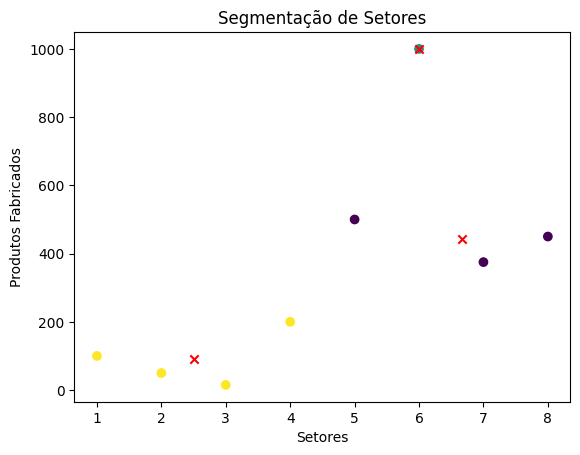

In [7]:
plt.scatter(dados[:,0], dados[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker="x", color="red")
plt.xlabel("Setores")
plt.ylabel("Produtos Fabricados")
plt.title("Segmentação de Setores")
plt.show()


In [8]:
from sklearn.metrics import silhouette_score
silhouette_score(dados, kmeans.predict(dados))
def avaliacao(dados):
 inercia = []
 silhueta = []
 for k in range(2,5):
    kmeans = KMeans(n_clusters=k, random_state=45, n_init='auto')
    kmeans.fit(dados)
    inercia.append(kmeans.inertia_)
    silhueta.append(f'k={k} - '+ str(silhouette_score(dados, kmeans.predict(dados))))

 return silhueta, inercia

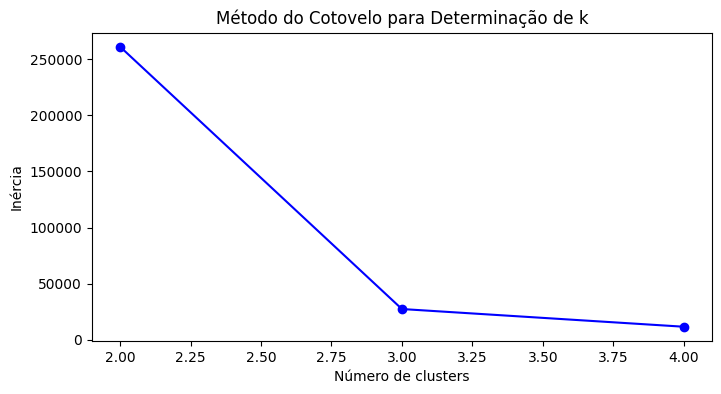

In [9]:
silhueta, inercia = avaliacao(dados)
silhueta
# analisando a metrica inercia
def plot_cotovelo(inercia):
    plt.figure(figsize=(8,4))
    plt.plot(range(2,5),inercia,'bo-')
    plt.xlabel('Número de clusters')
    plt.ylabel('Inércia')
    plt.title('Método do Cotovelo para Determinação de k')
    plt.show()

plot_cotovelo(inercia)

Valor médio para 2 clusters: 0.546


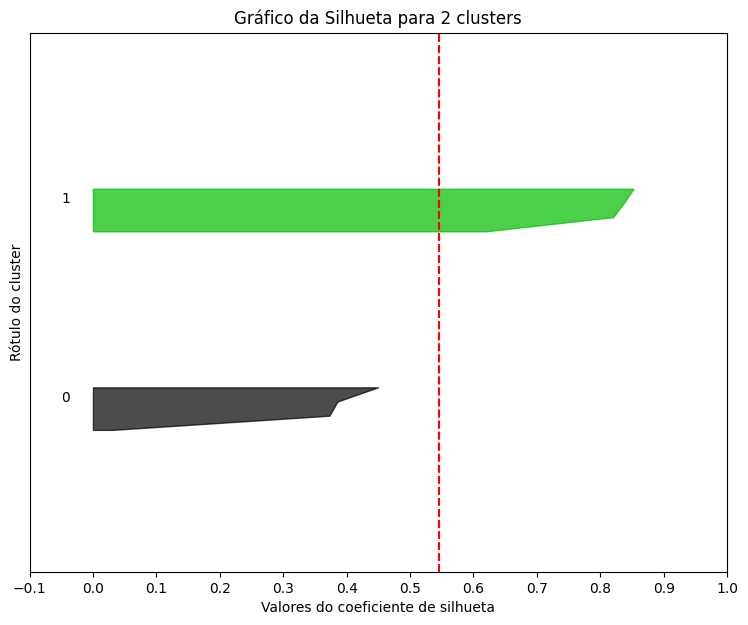

In [11]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples
def graf_silhueta (n_clusters, dados_n):
    # Aplica o KMeans ao conjunto de dados
    kmeans = KMeans(n_clusters=n_clusters, random_state=45, n_init = 'auto')
    cluster_previsoes = kmeans.fit_predict(dados_n)

    # Calcula o silhouette score médio
    silhueta_media = silhouette_score(dados_n, cluster_previsoes)
    print(f'Valor médio para {n_clusters} clusters: {silhueta_media:.3f}')

    # Calcula a pontuação de silhueta para cada amostra
    silhueta_amostra = silhouette_samples(dados_n, cluster_previsoes)

    # Configuração da figura para o gráfico de silhueta
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(9, 7)

    # Limites do gráfico de silhueta
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(dados_n) + (n_clusters + 1) * 10])

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhueta_amostra = silhueta_amostra[cluster_previsoes == i]
        ith_cluster_silhueta_amostra.sort()

        tamanho_cluster_i = ith_cluster_silhueta_amostra.shape[0]
        y_upper = y_lower + tamanho_cluster_i

        cor = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhueta_amostra,
        facecolor=cor, edgecolor=cor, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * tamanho_cluster_i, str(i))
        y_lower = y_upper + 10 # 10 para o espaço entre gráficos

        # Linha vertical para a média do Silhouette Score
        ax1.axvline(x=silhueta_media, color='red', linestyle='--')

        ax1.set_title(f'Gráfico da Silhueta para {n_clusters} clusters')
        ax1.set_xlabel('Valores do coeficiente de silhueta')
        ax1.set_ylabel('Rótulo do cluster')

        ax1.set_yticks([]) # Remove os ticks do eixo y
        ax1.set_xticks([i/10.0 for i in range(-1, 11)])

    plt.show()
graf_silhueta(2, dados)

In [12]:
# Exercício 4
dia_semana = [1,2,3,4,5,6,7]
clientes = [15,20,30,100,350,500,700]

In [16]:
dadosMaiorMov = np.column_stack((dia_semana, clientes))
dadosMaiorMov

array([[  1,  15],
       [  2,  20],
       [  3,  30],
       [  4, 100],
       [  5, 350],
       [  6, 500],
       [  7, 700]])

In [17]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(dadosMaiorMov)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [18]:
sse = kmeans.inertia_
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

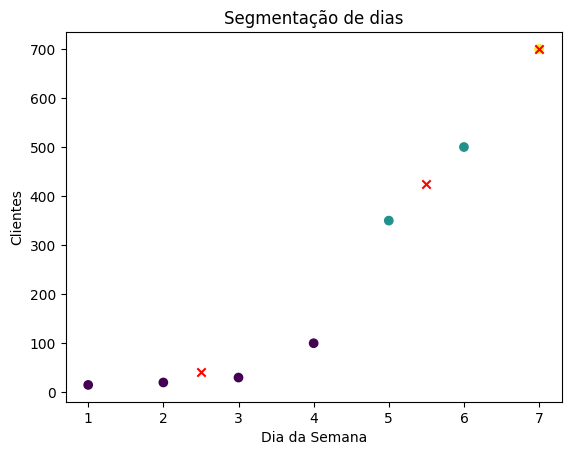

In [20]:
plt.scatter(dadosMaiorMov[:,0], dadosMaiorMov[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker="x", color="red")
plt.xlabel("Dia da Semana")
plt.ylabel("Clientes")
plt.title("Segmentação de dias")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(dadosMaiorMov, kmeans.predict(dadosMaiorMov))
def avaliacao(dadosMaiorMov):
 inercia = []
 silhueta = []
 for k in range(2,5):
    kmeans = KMeans(n_clusters=k, random_state=45, n_init='auto')
    kmeans.fit(dadosMaiorMov)
    inercia.append(kmeans.inertia_)
    silhueta.append(f'k={k} - '+ str(silhouette_score(dadosMaiorMov, kmeans.predict(dadosMaiorMov))))

 return silhueta, inercia

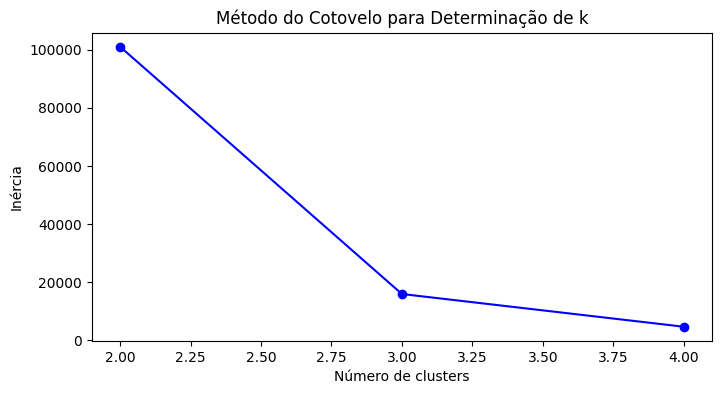

In [23]:
silhueta, inercia = avaliacao(dadosMaiorMov)
silhueta
# analisando a metrica inercia
def plot_cotovelo(inercia):
    plt.figure(figsize=(8,4))
    plt.plot(range(2,5),inercia,'bo-')
    plt.xlabel('Número de clusters')
    plt.ylabel('Inércia')
    plt.title('Método do Cotovelo para Determinação de k')
    plt.show()

plot_cotovelo(inercia)

Valor médio para 2 clusters: 0.596


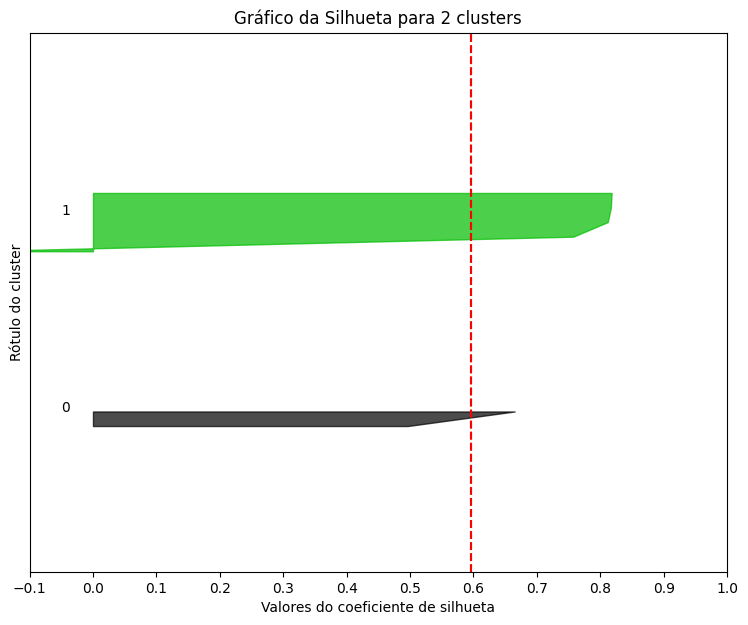

In [26]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples
def graf_silhueta (n_clusters, dados_n):
    # Aplica o KMeans ao conjunto de dados
    kmeans = KMeans(n_clusters=n_clusters, random_state=45, n_init = 'auto')
    cluster_previsoes = kmeans.fit_predict(dados_n)

    # Calcula o silhouette score médio
    silhueta_media = silhouette_score(dados_n, cluster_previsoes)
    print(f'Valor médio para {n_clusters} clusters: {silhueta_media:.3f}')

    # Calcula a pontuação de silhueta para cada amostra
    silhueta_amostra = silhouette_samples(dados_n, cluster_previsoes)

    # Configuração da figura para o gráfico de silhueta
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(9, 7)

    # Limites do gráfico de silhueta
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(dados_n) + (n_clusters + 1) * 10])

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhueta_amostra = silhueta_amostra[cluster_previsoes == i]
        ith_cluster_silhueta_amostra.sort()

        tamanho_cluster_i = ith_cluster_silhueta_amostra.shape[0]
        y_upper = y_lower + tamanho_cluster_i

        cor = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhueta_amostra,
        facecolor=cor, edgecolor=cor, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * tamanho_cluster_i, str(i))
        y_lower = y_upper + 10 # 10 para o espaço entre gráficos

        # Linha vertical para a média do Silhouette Score
        ax1.axvline(x=silhueta_media, color='red', linestyle='--')

        ax1.set_title(f'Gráfico da Silhueta para {n_clusters} clusters')
        ax1.set_xlabel('Valores do coeficiente de silhueta')
        ax1.set_ylabel('Rótulo do cluster')

        ax1.set_yticks([]) # Remove os ticks do eixo y
        ax1.set_xticks([i/10.0 for i in range(-1, 11)])

    plt.show()
graf_silhueta(2, dados)